In [3]:
import pandas as pd
import numpy as np

In [ ]:
path = r'../demo_data\heatmap_data.txt'

In [5]:
df = pd.read_csv(path, sep='\t')

df.head()

,ID,Sample,Compound ID,CV,AVGNorm
0,1,WT,Decane,0.356464,1.0
1,2,WT,Tetradecane,0.306147,1.0
2,3,WT,13-Methyltetradecanal,0.398923,1.0
3,4,WT,13-Methyltetradecanal,0.264344,1.0
4,5,WT,"Benzene, 1,3-bis(1,1-dimethylethyl)-",0.187798,1.0


In [6]:
# Create a unique identifier for each duplicate Compound ID within each Sample
df['Unique_Compound'] = df.groupby(['Sample', 'Compound ID']).cumcount()
df['Unique_Compound'] = df['Compound ID'] + '_' + df['Unique_Compound'].astype(str)

# Pivot the DataFrame for AVGNorm and CV
pivot_avg_norm = df.pivot(index='Unique_Compound', columns='Sample', values='AVGNorm')
pivot_cv = df.pivot(index='Unique_Compound', columns='Sample', values='CV')

pivot_avg_norm.head()

Sample,WT,cIDH,pIDH
Unique_Compound,,,
1-Octen-3-ol_0,1.0,0.723102,0.665752
13-Methyltetradecanal_0,1.0,0.388332,0.816762
13-Methyltetradecanal_1,1.0,0.653592,0.632015
2-BUTANONE_0,1.0,0.717215,0.671704
"2-BUTENAL, 2-METHYL-_0",1.0,0.510636,0.531648


In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.cm as cm
plt.style.use('default')

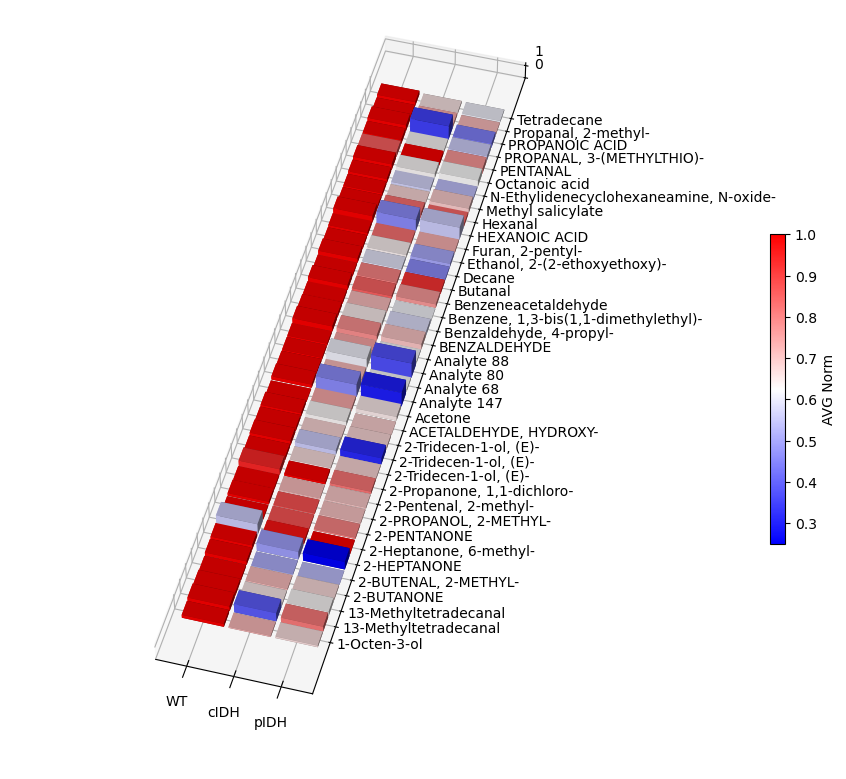

In [10]:
# Create a 3D plot
fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection='3d')

# Create a mesh of x, y values
x_labels = pivot_cv.columns
y_labels = [x[:-2] for x in pivot_cv.index]
x, y = np.meshgrid(np.arange(len(x_labels)), np.arange(len(y_labels)))

# Convert x, y, and z to 1D arrays
x = x.flatten()
y = y.flatten()
z = np.zeros_like(x)

# The height of the bars will be our CV values, scaled by a factor of 3
dx = np.ones_like(x)
dy = dx.copy()
dz = pivot_cv.values.flatten() 

# Map the AVGNorm values to colors using colormap
norm = plt.Normalize(pivot_avg_norm.values.min(), pivot_avg_norm.values.max())
cmap = cm.bwr
colors = cmap(norm(pivot_avg_norm.values.flatten()))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create the 3D bars
bars = ax.bar3d(x-0.45, y-0.45, z, dx-0.1, dy-0.1, dz, color=colors, shade=True)

# Add an axes at the top left of the figure for the colorbar
# The values in `fig.add_axes` are [left, bottom, width, height], which are fractions of figure width and height
#cbar_ax = fig.add_axes([0.35, 0.85, 0.15, 0.01])  # Adjust these values as needed
#cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar = fig.colorbar(sm, ax=ax, 
                    fraction=0.02, 
                    pad=0,
                    )

cbar.set_label('AVG Norm')

# Set the x and y axis labels
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, #rotation=90
                   )
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

#ax.set_zlim(0, 1)
# Set the z-axis to only show the min and max
z_min = 0
z_max = 1
ax.set_zticks([z_min, z_max])

# Adjust the scale of the axes to make Y-axis longer than X-axis
ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([0.5, 2.7, 0.1, 1.5]))

# Align y-tick labels to the right
for label in ax.get_yticklabels():
    label.set_horizontalalignment('left')
    label.set_verticalalignment('center')


# Hide grid
#ax.grid(False)


# Rotate the plot for a top-down view
ax.view_init(50, 285)  

# Show the plot
plt.show()
